In [1]:
%reload_ext autoreload
%autoreload 2

# add top repo dir to path so that src can be imported
import sys
sys.path.append("..")

%matplotlib inline
from src.data import load_raman_spectra, load_crystal_structures
import numpy as np
from collections import Counter
import torch_geometric as pyg
import codecs
import torch
from src.visualization import plotting
import pandas as pd

In [2]:
import re
pattern = re.compile(r"##ORIENTATION.*?[\(\[]\s*([-\d\s\.]+)\s*[\)\]].*?[\(\[]\s*([-\d\s\.]+)\s*[\)\]]")
raw = pattern.search("""##DESCRIPTION=Mass of green acicular to bladed crystals associated with chlorite
##STATUS=The identification of this mineral has been confirmed by X-ray diffraction and chemical analysis
##URL=rruff.info/R040063
##MEASURED CHEMISTRY=(Ca_1.90_Na_0.06_Mn_0.04_)_Σ=2_(Mg_4.35_Fe_0.65_)_Σ=5_(Si_7.92_Al_0.08_)_Σ=8_O_22_(OH)_2_
##PIN_ID=S00044
##ORIENTATION=Laser parallel to b* (0 -1 0). Fiducial mark perpendicular to laser is parallel to c [0 0 1]
141.323, 0.000
142.709, 24.612""").groups()
orientation_vec = [1] + [int(i) for row in raw for i in row.split(" ")]
orientation_vec

[1, 0, -1, 0, 0, 0, 1]

In [4]:
def filter_graphs(data_lst, wl_lst):
    valid = []
    validw = []
    removed = 0
    for i, d in enumerate(data_lst):
        if d.edge_index is not None and d.edge_index.size(1) != 0:
            valid.append(data_lst[i])
            validw.append(wl_lst[i])
            continue
        else:
            removed += 1
        if hasattr(d,"dist") and d.dist is not None:
            valid.append(data_lst[i])
            validw.append(wl_lst[i])
            continue
        else:
            removed += 1
    return valid, validw, removed

In [5]:
cif_mineral_names = []
cif_graphs = []
big_cif_file_path = '../data/raw/cifdata_10.txt'
temp_file_path = '../data/raw/tempcif.txt'
cur_mineral_name = ''
cur_cif_lines = []
with open(big_cif_file_path,'r',errors='ignore') as f:
    for line in f:
        if line.startswith("_chemical_formula_sum ''"):
            continue
        if line.startswith('_chemical_name_mineral'):
            cur_mineral_name = line.split("'")[1]
        if line.startswith('_amcsd_formula_title '):
            cur_mineral_name = line.split("'")[1]
        if line.startswith('END'):
            try:
                with codecs.open(temp_file_path,'w','utf-8') as out:
                    out.write(''.join(cur_cif_lines))
                _,G = load_crystal_structures.load_single_crystal_structure(
                                                    temp_file_path,
                                                    min_distance_for_edge=-1,
                                                    max_distance_for_edge=np.inf,
                                                    )
                cif_graphs.append(G)
                cif_mineral_names.append(cur_mineral_name)
            except:
                pass
            cur_cif_lines = []
        else:
            cur_cif_lines.append(line)

could not convert string to float: '–'
He
could not convert string to float: '–'
He
could not convert string to float: '–'
He
could not convert string to float: '–'
Ar
could not convert string to float: '–'
Ar
could not convert string to float: '–'
Ne
could not convert string to float: '–'
He
could not convert string to float: '–'
Ne
could not convert string to float: '–'
He
could not convert string to float: '–'
He
could not convert string to float: '–'
He
could not convert string to float: '–'
Ar
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float: '–'
Ne
could not convert string to float:

In [ ]:
model_wavenumber_values = np.load('../data/processed/wavenumber_vals_v3.npy')
data_list = []
wavelengths = []
for i in {514,532,780,785}:
    print("current wavelength: ",i)
    raman_file_paths, raman_mineral_names, raman_spectra, raman_wavelengths, cond_vec = load_raman_spectra.load_raman_data(model_wavenumber_values,wavelength=i,zero_pad=False)
    print(len(raman_mineral_names), "Raman spectra loaded, each of length", len(raman_spectra[0]))
    all_minerals = set(cif_mineral_names+raman_mineral_names)
    cif_counter = Counter(cif_mineral_names)
    raman_counter = Counter(raman_mineral_names)
    minimum_number_for_each = 1
    minerals_for_dataset = []
    for mineral in all_minerals:
        if cif_counter[mineral] >= minimum_number_for_each and raman_counter[mineral] >= minimum_number_for_each:
            minerals_for_dataset.append(mineral)
    try:
        minerals_for_dataset.remove('Diamond')
    except:
        print("no diamond at ",i)
    try:
        minerals_for_dataset.remove('Sulphur')
    except:
        print("no sulphur at ",i)
    try:
        minerals_for_dataset.remove('Silicon')
    except:
        print("no silicon at ",i)
    print(len(minerals_for_dataset),'/',len(all_minerals))
    for mineral in minerals_for_dataset:
        cur_mineral_raman_indices = [i for i, x in enumerate(raman_mineral_names) if x == mineral]
        cur_mineral_graph_indices = [i for i, x in enumerate(cif_mineral_names) if x == mineral]
        for i_raman, i_graph in zip(cur_mineral_raman_indices,cur_mineral_graph_indices):
            cur_graph = pyg.utils.convert.from_networkx(cif_graphs[i_graph])
            cur_graph['y'] = raman_spectra[i_raman]
            wavelengths.append(i/1e2)
            cur_graph['mineral'] = mineral
            data_list.append(cur_graph)
    data_list, wavelengths, removed = filter_graphs(data_list,wavelengths)
    print(f'left: {len(data_list)} wl: {len(wavelengths)}, removed: {removed}')
for g, wl in zip(data_list, wavelengths, ): 
    g.wl = torch.tensor([wl], dtype=torch.float32)
print((pd.DataFrame(wavelengths)).value_counts())

current wavelength:  785
2208 Raman spectra loaded, each of length 266
no silicon in  785
668 / 8218
left: 1233 wl: 1233, removed: 48
current wavelength:  514
12311 Raman spectra loaded, each of length 266
295 / 7993
left: 4108 wl: 4108, removed: 4
current wavelength:  532
7149 Raman spectra loaded, each of length 266
1470 / 8658
left: 7545 wl: 7545, removed: 82
current wavelength:  780
runtime warning at  ../data/raw/raman\unrated_unoriented\DecrespignyiteY__R060302__Raman__780__0__unoriented__Raman_Data_RAW__38764.txt
4550 Raman spectra loaded, each of length 266
1076 / 8405
left: 9941 wl: 9941, removed: 44
0   
5.32    3437
5.14    2875
7.80    2396
7.85    1233
Name: count, dtype: int64


In [ ]:
save_path = '../data/processed/v6.pt'
data, slices, _ = pyg.data.collate.collate(
    data_list[0].__class__,
    data_list=data_list,
    increment=False,
    add_batch=True,
)
data.x = data.x.type(torch.FloatTensor)
data.wl = torch.tensor(wavelengths, dtype=torch.float32)
data.pos = data.pos.type(torch.FloatTensor)
data.dist = data.dist.type(torch.FloatTensor)
data.y = torch.stack([torch.Tensor(yi) for yi in data.y]).type(torch.FloatTensor)

collated_data = (data, slices)
torch.save(collated_data, save_path)

In [20]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import codecs
from collections import Counter

import torch
import numpy as np
import pandas as pd
import torch_geometric as pyg
from tqdm import tqdm

sys.path.append("..")
from src.data import load_raman_spectra, load_crystal_structures

def filter_graphs(data_lst, wl_lst):
    valid = []
    validw = []
    removed = 0
    for i, d in enumerate(data_lst):
        if d.edge_index is not None and d.edge_index.size(1) != 0:
            valid.append(data_lst[i])
            validw.append(wl_lst[i])
            continue
        else:
            removed += 1
        if hasattr(d,"dist") and d.dist is not None:
            valid.append(data_lst[i])
            validw.append(wl_lst[i])
            continue
        else:
            removed += 1
    return valid, validw, removed

v6_data, _ = torch.load('../data/processed/v6.pt', weights_only=False)
v6_template = list(zip([m[0] if isinstance(m, list) else m for m in v6_data.mineral], [round(float(w), 3) for w in v6_data.wl]))

cif_mineral_names = []
cif_graphs = []
big_cif_file_path = '../data/raw/cifdata_10.txt'
temp_file_path = '../data/raw/tempcif.txt'
cur_mineral_name = ''
cur_cif_lines = []
i = 0

with open(big_cif_file_path, 'r', errors='ignore') as f:
    for line in tqdm(f,mininterval=1.0,leave=False):
        if line.startswith("_chemical_formula_sum ''"):
            continue
        if line.startswith('_chemical_name_mineral'):
            cur_mineral_name = line.split("'")[1]
        if line.startswith('_amcsd_formula_title '):
            cur_mineral_name = line.split("'")[1]
        if line.startswith('END'):
            i += 1
            if i <= 0:
                pass
            else:
                try:
                    with codecs.open(temp_file_path, 'w', 'utf-8') as out:
                        out.write(''.join(cur_cif_lines))
                    _, G = load_crystal_structures.load_single_crystal_structure(
                        temp_file_path,
                        min_distance_for_edge=1e-8,
                        max_distance_for_edge=8.0,
                        verbose=False
                    )
                    cif_graphs.append(G)
                    cif_mineral_names.append(cur_mineral_name)
                except:
                    pass
            cur_cif_lines = []
        else:
            cur_cif_lines.append(line)
max_folds = max([len(g.folds) for g in cif_graphs])

model_wavenumber_values = np.load('../data/processed/wavenumber_vals_v3.npy')
new_graphs_pool = {}

for i in [514, 532, 780, 785]:
    print("current wavelength: ", i)
    raman_file_paths, raman_mineral_names, raman_spectra, raman_wavelengths, cond_vecs = load_raman_spectra.load_raman_data(
        model_wavenumber_values, wavelength=i, zero_pad=False
    )
    print(len(raman_mineral_names), "Raman spectra loaded, each of length", len(raman_spectra[0]))
    
    all_minerals = sorted(list(set(cif_mineral_names + raman_mineral_names)))
    cif_counter = Counter(cif_mineral_names)
    raman_counter = Counter(raman_mineral_names)
    
    minerals_for_dataset = [m for m in all_minerals if cif_counter[m] >= 1 and raman_counter[m] >= 1]
    for skip in ['Diamond', 'Sulphur', 'Silicon']:
        if skip in minerals_for_dataset:
            minerals_for_dataset.remove(skip)
        else:
            print("no", skip.lower(), "at", i)
            
    print(len(minerals_for_dataset), '/', len(all_minerals))

    temp_data_list = []
    temp_wl_list = []
    wl_val = round(i / 100.0, 3)

    for mineral in minerals_for_dataset:
        cur_mineral_raman_indices = [idx for idx, x in enumerate(raman_mineral_names) if x == mineral]
        cur_mineral_graph_indices = [idx for idx, x in enumerate(cif_mineral_names) if x == mineral]

        for i_raman, i_graph in zip(cur_mineral_raman_indices, cur_mineral_graph_indices):
            cur_graph = pyg.utils.convert.from_networkx(cif_graphs[i_graph])
            cur_graph['y'] = raman_spectra[i_raman]
            cur_graph['mineral'] = mineral
            cur_graph['cond_vec'] = cond_vecs[i_raman]
            cur_graph['cell_params'] = torch.tensor(cif_graphs[i_graph].cell_params, dtype=torch.float32).view(1, -1)
            cur_graph['folds'] = torch.tensor([0] * (max_folds - len(cif_graphs[i_graph].folds)) + cif_graphs[i_graph].folds, dtype=torch.long).view(1, -1)
            
            temp_data_list.append(cur_graph)
            temp_wl_list.append(wl_val)

    valid_graphs, valid_wls, removed = filter_graphs(temp_data_list, temp_wl_list)
    print(f'left: {len(valid_graphs)} wl: {len(valid_wls)}, removed: {removed}')

    for g, w in zip(valid_graphs, valid_wls):
        key = (g['mineral'], w)
        if key not in new_graphs_pool:
            new_graphs_pool[key] = []
        new_graphs_pool[key].append(g)

data_list = []
wavelengths = []

for mineral, wl in v6_template:
    if (mineral, wl) in new_graphs_pool and len(new_graphs_pool[(mineral, wl)]) > 0:
        graph = new_graphs_pool[(mineral, wl)].pop(0)
        graph.wl = torch.tensor([wl], dtype=torch.float32)
        data_list.append(graph)
        wavelengths.append(wl)

for (mineral, wl), graphs in new_graphs_pool.items():
    for graph in graphs:
        graph.wl = torch.tensor([wl], dtype=torch.float32)
        data_list.append(graph)
        wavelengths.append(wl)

print((pd.DataFrame(wavelengths)).value_counts())

data, slices, _ = pyg.data.collate.collate(
    data_list[0].__class__,
    data_list=data_list,
    increment=False,
    add_batch=True,
)

data.x = data.x.type(torch.FloatTensor)
data.wl = torch.tensor(wavelengths, dtype=torch.float32)
data.pos = data.pos.type(torch.FloatTensor)
data.dist = data.dist.type(torch.FloatTensor)
data.y = torch.stack([torch.Tensor(yi) for yi in data.y]).type(torch.FloatTensor)
data.cond_vec = torch.stack([torch.Tensor(cv) for cv in data.cond_vec]).type(torch.FloatTensor)
data.cell_params = torch.stack([torch.Tensor(cp) for cp in data.cell_params]).type(torch.FloatTensor)
data.folds = torch.stack([torch.Tensor(f) for f in data.folds]).type(torch.LongTensor)

torch.save((data, slices), '../data/processed/v7.pt')

current wavelength:  514
12279 Raman spectra loaded, each of length 266
314 / 8765
left: 3018 wl: 3018, removed: 6
current wavelength:  532
7149 Raman spectra loaded, each of length 266
1702 / 9217
left: 3821 wl: 3821, removed: 98
current wavelength:  780
4551 Raman spectra loaded, each of length 266
1246 / 9027
left: 2660 wl: 2660, removed: 54
current wavelength:  785
2208 Raman spectra loaded, each of length 266
no silicon at 785
748 / 8929
left: 1368 wl: 1368, removed: 56
0   
5.32    3821
5.14    3018
7.80    2660
7.85    1368
Name: count, dtype: int64


In [3]:
%reload_ext autoreload
%autoreload 2
# import codecs
from src.data.load_crystal_structures import  load_single_crystal_structure
edingtonite_path = "../data/test/edingtonite.cif"
# with codecs.open(edingtonite_path,'w','utf-8') as out:
#     out.write(''.join(cur_cif_lines))
wl = [5.14,5.32,7.8,7.85]
for i in wl:
    _,G = load_single_crystal_structure(
                                        edingtonite_path,
                                        min_distance_for_edge=-1,
                                        max_distance_for_edge=10,
                                        )


In [1]:
import sys
sys.path.append("..")
from src.data.dataset import Crystals
from torch_geometric.loader import DataLoader

dataset = Crystals("../data/processed/v7.pt")
dataloader = DataLoader(dataset, batch_size=1)
dataloader = list(iter(dataloader))
data = dataloader[0]

In [22]:
dataloader = DataLoader(dataset, batch_size=64)
dataloader = list(iter(dataloader))
data = dataloader[0]

In [2]:
dataloader[0]

DataBatch(x=[21, 8], edge_index=[2, 414], pos=[21, 3], element=[1], z=[21], dist=[414], y=[1, 266], mineral=[1], cond_vec=[1, 7], cell_params=[1, 6], folds=[1, 4], wl=[1], batch=[21], ptr=[2])

In [24]:
dataloader[0].folds

tensor([[0, 0, 1, 2],
        [0, 0, 1, 2],
        [0, 0, 1, 2],
        [0, 0, 1, 2],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [0, 0, 1, 2],
        [1, 2, 3, 4],
        [0, 0, 0, 1],
        [0, 0, 1, 2],
        [0, 0, 0, 1],
        [1, 2, 3, 4],
        [1, 2, 3, 4],
        [0, 0, 1, 3],
        [0, 0, 1, 3],
        [0, 0, 1, 3],
        [0, 0, 1, 3],
        [0, 0, 1, 3],
        [0, 0, 1, 3],
        [0

In [16]:
i = 2
print(dataloader[i].folds)

tensor([1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6,
        1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6,
        1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6,
        1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 3, 6, 1, 2, 1, 2, 1, 2, 3, 6,
        1, 2, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 4, 1, 2, 4, 1, 1, 2, 3, 1, 2, 3,
        1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3,
        1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3,
        1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 4, 1, 2, 4, 1, 2, 4,
        1, 2, 4, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2])


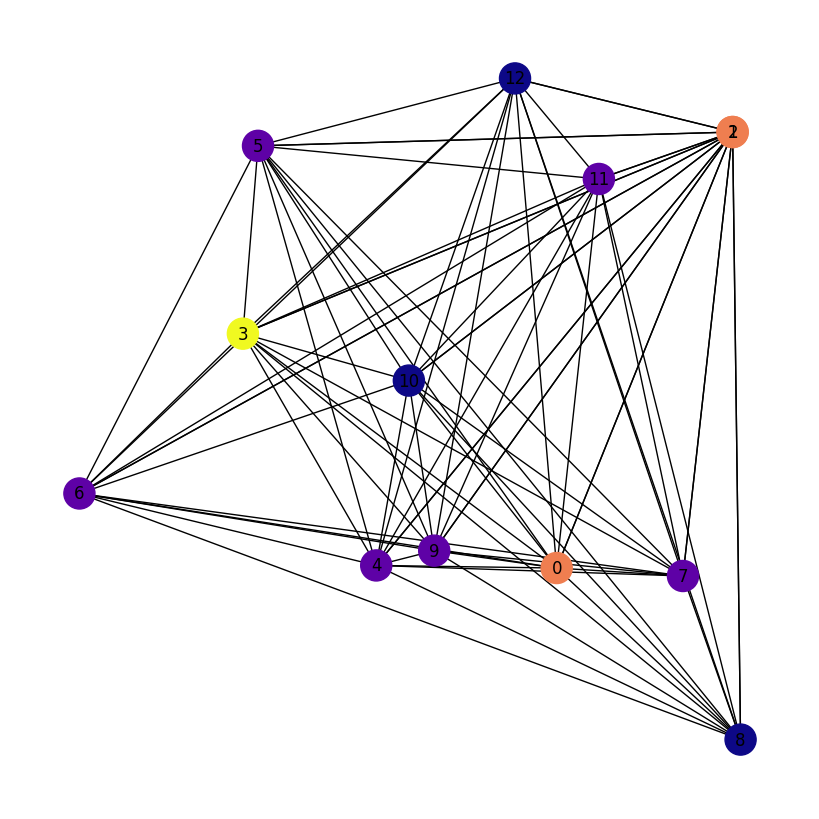

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

# Get the first graph
single_data = data.to_data_list()[2]
G = to_networkx(single_data, node_attrs=['z', 'pos'], to_undirected=True)

# Plotting the X-Y plane (Looking down the laser beam)
pos_2d = {i: d['pos'][:2] for i, d in G.nodes(data=True)}

plt.figure(figsize=(8, 8))
nx.draw(G, pos_2d, node_color=[d['z'] for i, d in G.nodes(data=True)], 
        with_labels=True, node_size=500, cmap=plt.cm.plasma)
plt.show()

In [17]:
data

DataBatch(x=[21, 8], edge_index=[2, 420], pos=[21, 3], element=[1], z=[21], dist=[420], y=[1, 266], mineral=[1], wl=[1], batch=[21], ptr=[2], cond_vec=[1, 7], edge_attr=[420, 2])

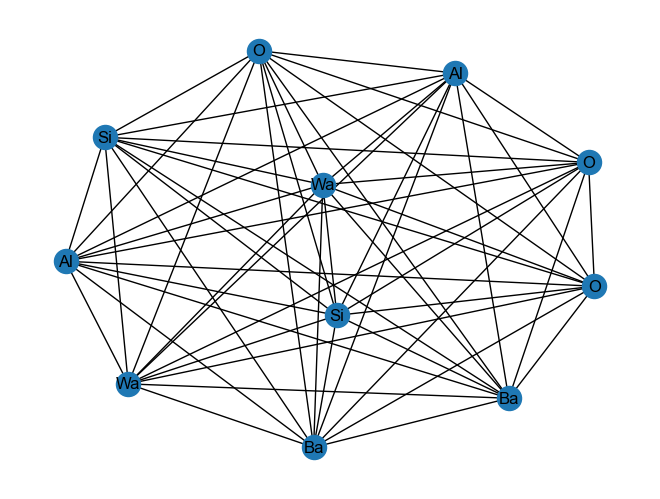

In [4]:
import networkx as nx
nx.draw(G,labels=nx.get_node_attributes(G,"element"))

In [5]:
from torch_geometric.utils import from_networkx
data = from_networkx(G)

D:\pycharm\graph12\.venv\Lib\site-packages\torch_geometric\utils\convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  data_dict[key] = torch.as_tensor(value)


In [7]:
datas = [data.__copy__(),data.__copy__(),data.__copy__(),data.__copy__()]
import torch
for d in datas:
    if hasattr(d, 'x') and d.x is not None:
        d.x = d.x.float()
    if hasattr(d, 'pos') and d.pos is not None:
        d.pos = d.pos.float()
    if hasattr(d, 'dist') and d.dist is not None:
        d.dist = d.dist.float()
datas[0]["wl"] = torch.tensor([5.14], dtype=torch.float32)
datas[1]["wl"] = torch.tensor([5.32], dtype=torch.float32)
datas[2]["wl"] = torch.tensor([7.8], dtype=torch.float32)
datas[3]["wl"] = torch.tensor([7.85], dtype=torch.float32)
datas

[Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=[1]),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=[1]),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=[1]),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=[1])]

In [14]:
from src.visualization.plotting import plot_one_dataset
from torch_geometric.loader import DataLoader
for i in DataLoader(datas,batch_size=1):
    pred = painn(i).detach().cpu().numpy().flatten()
    plot_one_dataset(pred, title = f"edingtonite {round(i.wl.item()*100)} nm", save_dir="predict/test")

In [17]:
from torch_geometric.loader import DataLoader

dataset = datas
dataloader = DataLoader(dataset, batch_size=1)
dataloader = list(iter(dataloader))

In [1]:
from src.data.dataset import Crystals
from torch_geometric.loader import DataLoader

dataset = Crystals("../data/processed/v6.pt")
dataloader = DataLoader(dataset, batch_size=1)
dataloader = list(iter(dataloader))
dataloader[0]

ModuleNotFoundError: No module named 'src'

In [19]:
dataloader[0]

tensor([ 0, 11])

[Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=5.14),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=5.32),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=7.8),
 Data(x=[11, 8], edge_index=[2, 110], pos=[11, 3], element=[11], z=[11], dist=[110], wl=7.85)]

In [20]:
wavenumbers

array([ 128.146,  133.696,  139.243,  144.787,  150.327,  155.863,
        161.396,  166.926,  172.452,  177.974,  183.493,  189.008,
        194.52 ,  200.029,  205.534,  211.035,  216.533,  222.027,
        227.518,  233.006,  238.49 ,  243.97 ,  249.448,  254.921,
        260.391,  265.858,  271.321,  276.781,  282.237,  287.69 ,
        293.14 ,  298.586,  304.029,  309.468,  314.903,  320.336,
        325.765,  331.19 ,  336.612,  342.031,  347.446,  352.858,
        358.267,  363.672,  369.073,  374.471,  379.866,  385.258,
        390.646,  396.031,  401.412,  406.79 ,  412.165,  417.536,
        422.904,  428.268,  433.629,  438.987,  444.342,  449.693,
        455.041,  460.385,  465.726,  471.064,  476.398,  481.729,
        487.057,  492.382,  497.703,  503.02 ,  508.335,  513.646,
        518.954,  524.259,  529.56 ,  534.858,  540.152,  545.444,
        550.732,  556.017,  561.298,  566.576,  571.851,  577.123,
        582.391,  587.657,  592.918,  598.177,  603.432,  608.

In [ ]:
import numpy as np
import sys
from workdir.config import wavenumbers
import matplotlib.pyplot as plt
source_x = np.linspace(200, 1000, 2000)
source_y = np.exp(-((source_x - 500)**2) / (2 * 20**2)) 
interp = np.interp(wavenumbers,source_x,source_y)
plt.plot(source_x, source_y, label='Original')
plt.plot(wavenumbers, interp, 'o', label='Interpolated')
plt.show()

ModuleNotFoundError: No module named 'src.loss'

In [ ]:
interp.shape

(266,)